In [1]:
import pandas as pd
raw = pd.read_csv(r'C:\Users\MrLaptop\Desktop\lngg.csv', encoding='latin-1')
raw

,Text,language
0,klement gottwaldi surnukeha palsameeriti ning ...,Estonian
1,sebes joseph pereira thomas pÃ¥ eng the jesui...,Swedish
2,à¸à¸à¸à¹à¸à¸£à¸´à¸à¸à¸£à¸¸à¸ à¸­à¸±à¸...,Thai
3,à®µà®¿à®à®¾à®à®ªà¯à®ªà®à¯à®à®¿à®©à®®à¯ ...,Tamil
4,de spons behoort tot het geslacht haliclona en...,Dutch
...,...,...
21995,hors du terrain les annÃ©es et sont des annÃ...,French
21996,à¹à¸ à¸à¸¨ à¸«à¸¥à¸±à¸à¸à¸²à¸à¸à¸µà¹à...,Thai
21997,con motivo de la celebraciÃ³n del septuagÃ©sim...,Spanish
21998,å¹´æï¼ç¶æéåªææ­²çå¥¹å¨ç¾ååºé...,Chinese


In [3]:
# Languages
languages = set(raw['language'])
print('Languages', languages)
print('========')
# Examples of multiple langs taken from heads and tails
print('Swedish & English:', raw['Text'][1])
print('Thai & English:', raw['Text'][2])
print('Chinese & English:', raw['Text'][21998])

Languages {'Urdu', 'Chinese', 'Latin', 'Japanese', 'Swedish', 'Dutch', 'Indonesian', 'Hindi', 'Arabic', 'Portugese', 'Spanish', 'Turkish', 'Romanian', 'Tamil', 'Pushto', 'Korean', 'French', 'Estonian', 'Thai', 'Persian', 'Russian', 'English'}
Swedish & English: sebes joseph pereira thomas  pÃ¥ eng the jesuits and the sino-russian treaty of nerchinsk  the diary of thomas pereira bibliotheca instituti historici s i --   rome libris 
Thai & English: à¸à¸à¸à¹à¸à¸£à¸´à¸à¸à¸£à¸¸à¸ à¸­à¸±à¸à¸©à¸£à¹à¸£à¸¡à¸±à¸ thanon charoen krung à¹à¸£à¸´à¹à¸¡à¸à¸±à¹à¸à¹à¸à¹à¸à¸à¸à¸ªà¸à¸²à¸¡à¹à¸à¸¢à¸à¸¶à¸à¹à¸¡à¹à¸à¹à¸³à¹à¸à¹à¸²à¸à¸£à¸°à¸¢à¸²à¸à¸µà¹à¸à¸à¸à¸à¸ à¸à¸£à¸¸à¸à¹à¸à¸à¸¡à¸«à¸²à¸à¸à¸£ à¹à¸à¹à¸à¸à¸à¸à¸£à¸¸à¹à¸à¹à¸£à¸à¸à¸µà¹à¹à¸à¹à¹à¸à¸à¸à¸´à¸à¸à¸²à¸£à¸ªà¸£à¹à¸²à¸à¹à¸à¸à¸à¸°à¸§à¸±à¸à¸à¸ à¸à¸±à¸à¸à¸¸à¸à¸±à¸à¸à¹à¸²à¸à¸à¸·à¹à¸à¸à¸µà¹à¹à¸à¸à¸à¸£à¸°à¸à¸à¸£ à¹à¸à¸à¸à¹à¸­à¸¡à¸à¸£à¸²à¸à¸¨à¸±à¸à¸£à¸¹à¸à¹à¸²

In [4]:
import numpy as np
from sklearn.model_selection import train_test_split

X=raw['Text']
y=raw['language']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test))

17600
4400
17600
4400


In [5]:
# Extract Unigrams
from sklearn.feature_extraction.text import CountVectorizer
unigramVectorizer = CountVectorizer(analyzer='char', ngram_range=(1,1))
X_unigram_train_raw = unigramVectorizer.fit_transform(X_train)
X_unigram_test_raw = unigramVectorizer.transform(X_test)


unigramFeatures = unigramVectorizer.get_feature_names_out()

print('Number of unigrams in training set:', len(unigramFeatures))

Number of unigrams in training set: 137


In [6]:
# Aggregate Unigrams per language
def train_lang_dict(X_raw_counts, y_train):
    lang_dict = {}
    for i in range(len(y_train)):
        lang = y_train[i]
        v = np.array(X_raw_counts[i])
        if not lang in lang_dict:
            lang_dict[lang] = v
        else:
            lang_dict[lang] += v
            
    # to relative
    for lang in lang_dict:
        v = lang_dict[lang]
        lang_dict[lang] = v / np.sum(v)
        
    return lang_dict

language_dict_unigram = train_lang_dict(X_unigram_train_raw.toarray(), y_train.values)

# Collect relevant chars per language
def getRelevantCharsPerLanguage(features, language_dict, significance=1e-5):
    relevantCharsPerLanguage = {}
    for lang in languages:
        chars = []
        relevantCharsPerLanguage[lang] = chars
        v = language_dict[lang]
        for i in range(len(v)):
            if v[i] > significance:
                chars.append(features[i])
    return relevantCharsPerLanguage

relevantCharsPerLanguage = getRelevantCharsPerLanguage(unigramFeatures, language_dict_unigram)
    
# Print number of unigrams per language
for lang in languages:    
    print(lang, len(relevantCharsPerLanguage[lang]))

Urdu 104
Chinese 109
Latin 113
Japanese 111
Swedish 97
Dutch 70
Indonesian 111
Hindi 99
Arabic 93
Portugese 81
Spanish 83
Turkish 106
Romanian 103
Tamil 88
Pushto 104
Korean 119
French 77
Estonian 87
Thai 107
Persian 93
Russian 82
English 87


In [7]:
# number of bigrams
from sklearn.feature_extraction.text import CountVectorizer
bigramVectorizer = CountVectorizer(analyzer='char', ngram_range=(2,2))
X_bigram_raw = bigramVectorizer.fit_transform(X_train)
bigramFeatures = bigramVectorizer.get_feature_names_out()
print('Number of bigrams', len(bigramFeatures))

Number of bigrams 8555


In [12]:
# top bigrams (>1%) for Spanish, Italian (Latin), English, Dutch, Chinese, Japanese, Korean
language_dict_bigram = train_lang_dict(X_bigram_raw.toarray(), y_train.values)
relevantCharsPerLanguage = getRelevantCharsPerLanguage(bigramFeatures, language_dict_bigram, significance=1e-2)
print('Spanish', relevantCharsPerLanguage['Spanish'])
print('Italian (Latin)', relevantCharsPerLanguage['Latin'])
print('English', relevantCharsPerLanguage['English'])
print('Dutch', relevantCharsPerLanguage['Dutch'])
print('Chinese', relevantCharsPerLanguage['Chinese'])
print('Japanese', relevantCharsPerLanguage['Japanese'])

Spanish [' a', ' c', ' d', ' e', ' l', ' p', ' s', 'a ', 'ar', 'de', 'e ', 'el', 'en', 'er', 'es', 'l ', 'la', 'n ', 'o ', 'os', 'ra', 's ']
Italian (Latin) [' a', ' c', ' e', ' i', 'a ', 'an', 'at', 'e ', 'er', 'in', 'is', 'it', 'li', 'm ', 'ri', 's ', 't ', 'ta', 'ti', 'um', 'us']
English [' a', ' i', ' o', ' s', ' t', 'an', 'd ', 'e ', 'er', 'he', 'in', 'n ', 'on', 're', 's ', 't ', 'th']
Dutch [' d', ' e', ' v', 'an', 'de', 'e ', 'ee', 'en', 'er', 'ge', 'in', 'n ', 'r ', 's ', 't ', 'te']
Chinese ['¼\x8c', 'ã\x80', 'ä¸', 'ï¼']
Japanese ['\x81®', 'ã\x80', 'ã\x81', 'ã\x82', 'ã\x83']


In [14]:
# Uni- & Bi-Gram Mixture CountVectorizer for top 1% features
from sklearn.feature_extraction.text import CountVectorizer

top1PrecentMixtureVectorizer = CountVectorizer(analyzer='char', ngram_range=(1,2), min_df=1e-2)
X_top1Percent_train_raw = top1PrecentMixtureVectorizer.fit_transform(X_train)
X_top1Percent_test_raw = top1PrecentMixtureVectorizer.transform(X_test)

language_dict_top1Percent = train_lang_dict(X_top1Percent_train_raw.toarray(), y_train.values)

top1PercentFeatures = top1PrecentMixtureVectorizer.get_feature_names_out()
print('Length of features', len(top1PercentFeatures))
print('')

#Unique features per language
relevantChars_Top1Percent = getRelevantCharsPerLanguage(top1PercentFeatures, language_dict_top1Percent, 1e-5)
for lang in relevantChars_Top1Percent:
    print("{}: {}".format(lang, len(relevantChars_Top1Percent[lang])))

Length of features 2478

Swedish: 601
Tamil: 307
Korean: 1031
Portugese: 573
Spanish: 567
Japanese: 1346
Pushto: 640
English: 536
Arabic: 352
Russian: 337
Hindi: 381
French: 570
Estonian: 674
Thai: 426
Romanian: 636
Indonesian: 578
Latin: 674
Urdu: 530
Dutch: 571
Turkish: 685
Chinese: 1367
Persian: 341


In [15]:
def getRelevantGramsPerLanguage(features, language_dict, top=50):
    relevantGramsPerLanguage = {}
    for lang in languages:
        chars = []
        relevantGramsPerLanguage[lang] = chars
        v = language_dict[lang]
        sortIndex = (-v).argsort()[:top]
        for i in range(len(sortIndex)):
            chars.append(features[sortIndex[i]])
    return relevantGramsPerLanguage

top50PerLanguage_dict = getRelevantGramsPerLanguage(top1PercentFeatures, language_dict_top1Percent)

# top50
allTop50 = []
for lang in top50PerLanguage_dict:
    allTop50 += set(top50PerLanguage_dict[lang])

top50 = list(set(allTop50))
    
print('All items:', len(allTop50))
print('Unique items:', len(top50))

All items: 1100
Unique items: 413


In [16]:
# getRelevantColumnIndices
def getRelevantColumnIndices(allFeatures, selectedFeatures):
    relevantColumns = []
    for feature in selectedFeatures:
        relevantColumns = np.append(relevantColumns, np.where(allFeatures==feature))
    return relevantColumns.astype(int)

relevantColumnIndices = getRelevantColumnIndices(np.array(top1PercentFeatures), top50)


X_top50_train_raw = np.array(X_top1Percent_train_raw.toarray()[:,relevantColumnIndices])
X_top50_test_raw = X_top1Percent_test_raw.toarray()[:,relevantColumnIndices] 

print('train shape', X_top50_train_raw.shape)
print('test shape', X_top50_test_raw.shape)

train shape (17600, 413)
test shape (4400, 413)


In [17]:
# Define some functions for our purpose

from sklearn.preprocessing import normalize
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, f1_score
import seaborn as sn
import matplotlib.pyplot as plt
import scipy

# Utils for conversion of different sources into numpy array
def toNumpyArray(data):
    data_type = type(data)
    if data_type == np.ndarray:
        return data
    elif data_type == list:
        return np.array(data_type)
    elif data_type == scipy.sparse.csr.csr_matrix:
        return data.toarray()
    print(data_type)
    return None


def normalizeData(train, test):
    train_result = normalize(train, norm='l2', axis=1, copy=True, return_norm=False)
    test_result = normalize(test, norm='l2', axis=1, copy=True, return_norm=False)
    return train_result, test_result

def applyNaiveBayes(X_train, y_train, X_test):
    trainArray = toNumpyArray(X_train)
    testArray = toNumpyArray(X_test)
    
    clf = MultinomialNB()
    clf.fit(trainArray, y_train)
    y_predict = clf.predict(testArray)
    return y_predict

def plot_F_Scores(y_test, y_predict):
    f1_micro = f1_score(y_test, y_predict, average='micro')
    f1_macro = f1_score(y_test, y_predict, average='macro')
    f1_weighted = f1_score(y_test, y_predict, average='weighted')
    print("F1: {} (micro), {} (macro), {} (weighted)".format(f1_micro, f1_macro, f1_weighted))

def plot_Confusion_Matrix(y_test, y_predict, color="Blues"):
    allLabels = list(set(list(y_test) + list(y_predict)))
    allLabels.sort()
    confusionMatrix = confusion_matrix(y_test, y_predict, labels=allLabels)
    unqiueLabel = np.unique(allLabels)
    df_cm = pd.DataFrame(confusionMatrix, columns=unqiueLabel, index=unqiueLabel)
    df_cm.index.name = 'Actual'
    df_cm.columns.name = 'Predicted'

    sn.set(font_scale=0.8) # for label size
    sn.set(rc={'figure.figsize':(15, 15)})
    sn.heatmap(df_cm, cmap=color, annot=True, annot_kws={"size": 12}, fmt='g')# font size
    plt.show()



C:\Users\MrLaptop\AppData\Local\Temp\ipykernel_5648\241283787.py:17: DeprecationWarning: Please use `csr_matrix` from the `scipy.sparse` namespace, the `scipy.sparse.csr` namespace is deprecated.
  elif data_type == scipy.sparse.csr.csr_matrix:


F1: 0.9602272727272727 (micro), 0.9618169519504193 (macro), 0.9616053620287907 (weighted)


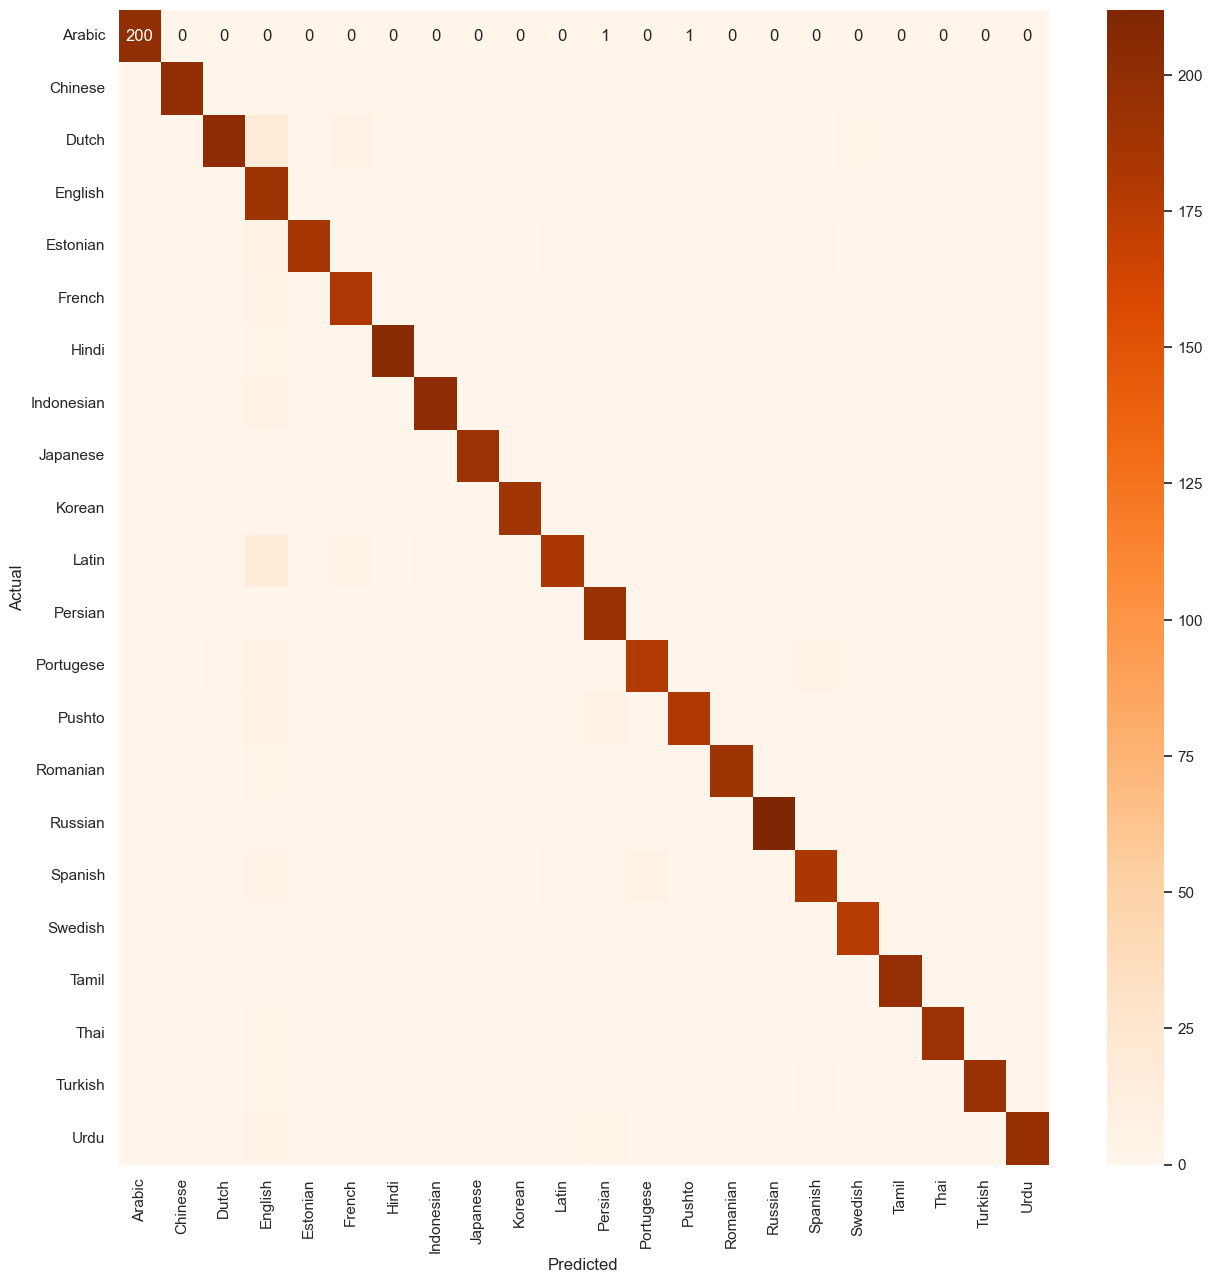

In [18]:
# Unigrams
X_unigram_train, X_unigram_test = normalizeData(X_unigram_train_raw, X_unigram_test_raw)
y_predict_nb_unigram = applyNaiveBayes(X_unigram_train, y_train, X_unigram_test)
plot_F_Scores(y_test, y_predict_nb_unigram)
plot_Confusion_Matrix(y_test, y_predict_nb_unigram, "Oranges")

C:\Users\MrLaptop\AppData\Local\Temp\ipykernel_5648\241283787.py:17: DeprecationWarning: Please use `csr_matrix` from the `scipy.sparse` namespace, the `scipy.sparse.csr` namespace is deprecated.
  elif data_type == scipy.sparse.csr.csr_matrix:


F1: 0.9736363636363636 (micro), 0.9744963001605268 (macro), 0.9744899899550321 (weighted)


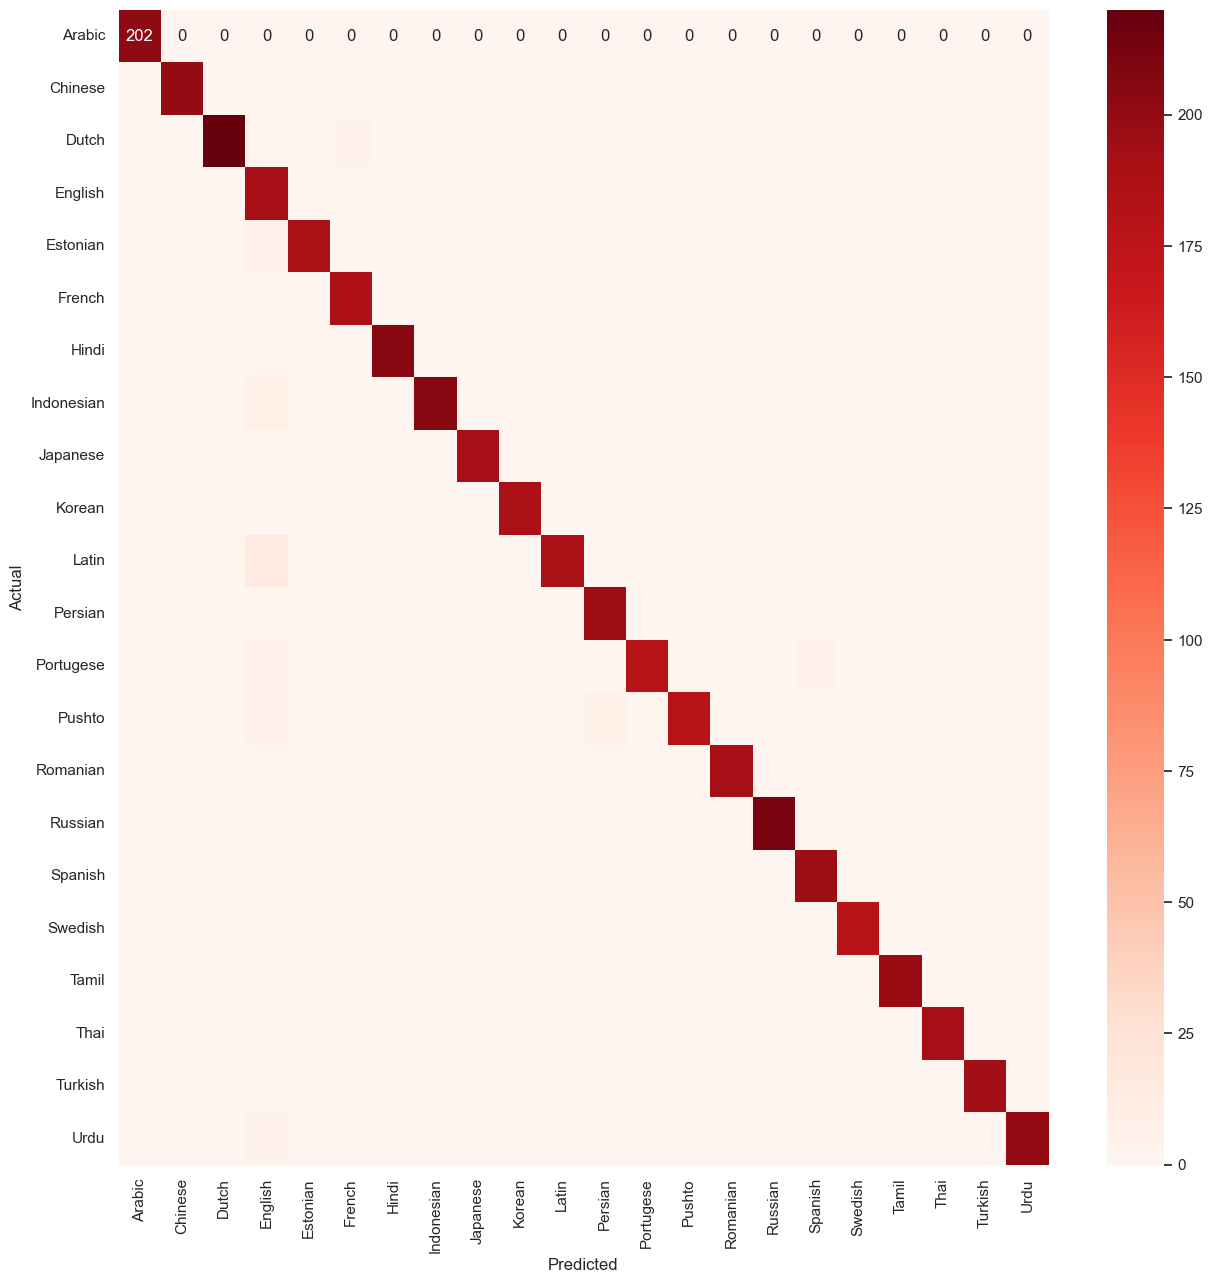

In [19]:
# Top 1%
X_top1Percent_train, X_top1Percent_test = normalizeData(X_top1Percent_train_raw, X_top1Percent_test_raw)
y_predict_nb_top1Percent = applyNaiveBayes(X_top1Percent_train, y_train, X_top1Percent_test)
plot_F_Scores(y_test, y_predict_nb_top1Percent)
plot_Confusion_Matrix(y_test, y_predict_nb_top1Percent, "Reds")

F1: 0.9720454545454545 (micro), 0.9726125217187616 (macro), 0.9725707121161425 (weighted)


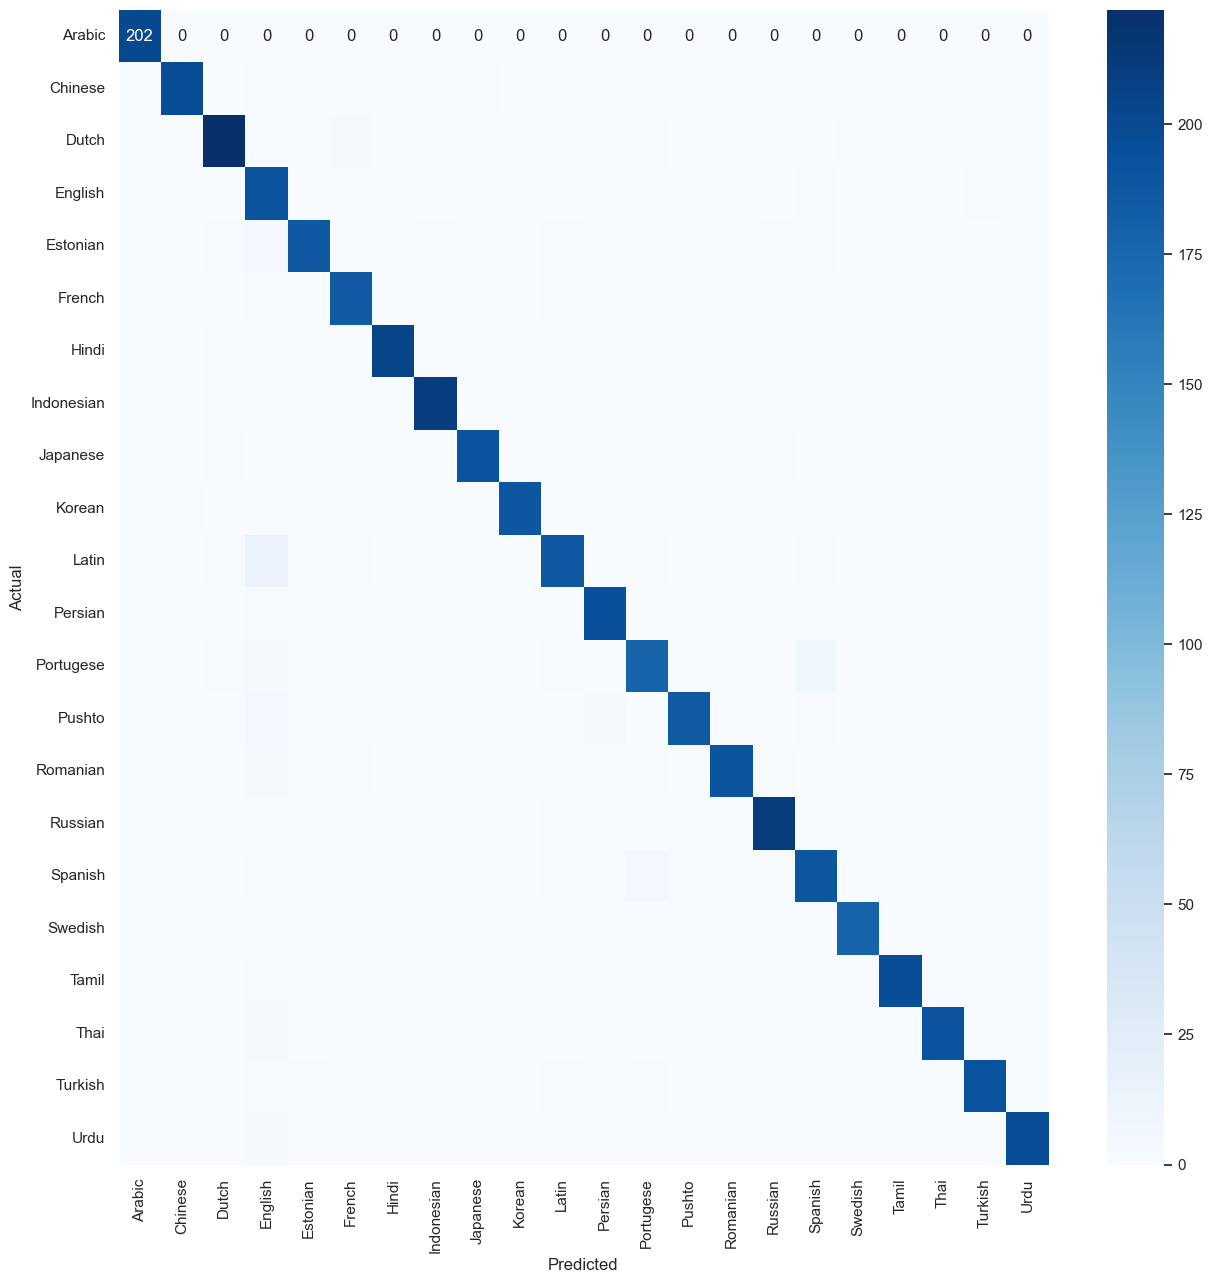

In [21]:
from sklearn.neighbors import KNeighborsClassifier

def applyNearestNeighbour(X_train, y_train, X_test):
    trainArray = toNumpyArray(X_train)
    testArray = toNumpyArray(X_test)
    
    clf = KNeighborsClassifier()
    clf.fit(trainArray, y_train)
    y_predict = clf.predict(testArray)
    return y_predict


## Unigrams
#y_predict_knn_unigram = applyNearestNeighbour(X_unigram_train, y_train, X_unigram_test)
#plot_F_Scores(y_test, y_predict_knn_unigram)
#plot_Confusion_Matrix(y_test, y_predict_knn_unigram, "Purples")

# Top 50
y_predict_knn_top50 = applyNearestNeighbour(X_top50_train, y_train, X_top50_test)
plot_F_Scores(y_test, y_predict_knn_top50)
plot_Confusion_Matrix(y_test, y_predict_knn_top50, "Blues")